In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import requests
from scipy import stats as sts
import io
import numpy as np
import matplotlib.pyplot as plt
import sys # for better in-place print statements
import networkx as nx



### Importing the Data

In [2]:
# Specify the URL of the data tile
url = (
    'https://storage.googleapis.com/earthenginepartners-hansen/GFC-2019-v1.7/Hansen_GFC-2019-v1.7_treecover2000_60N_000E.tif')

In [3]:
# Load the data into a NumPy array. It might take a minute to
# download the data since these data tiles are large.
Image.MAX_IMAGE_PIXELS = None
data_tile = np.array(
    Image.open(
        io.BytesIO(
            requests.get(url).content)))

In [4]:
# Each data tile is 40,000 x 40,000 and contains values from 0
# to 100, indicating the percentage tree cover in each grid cell.
data_tile.shape

(40000, 40000)

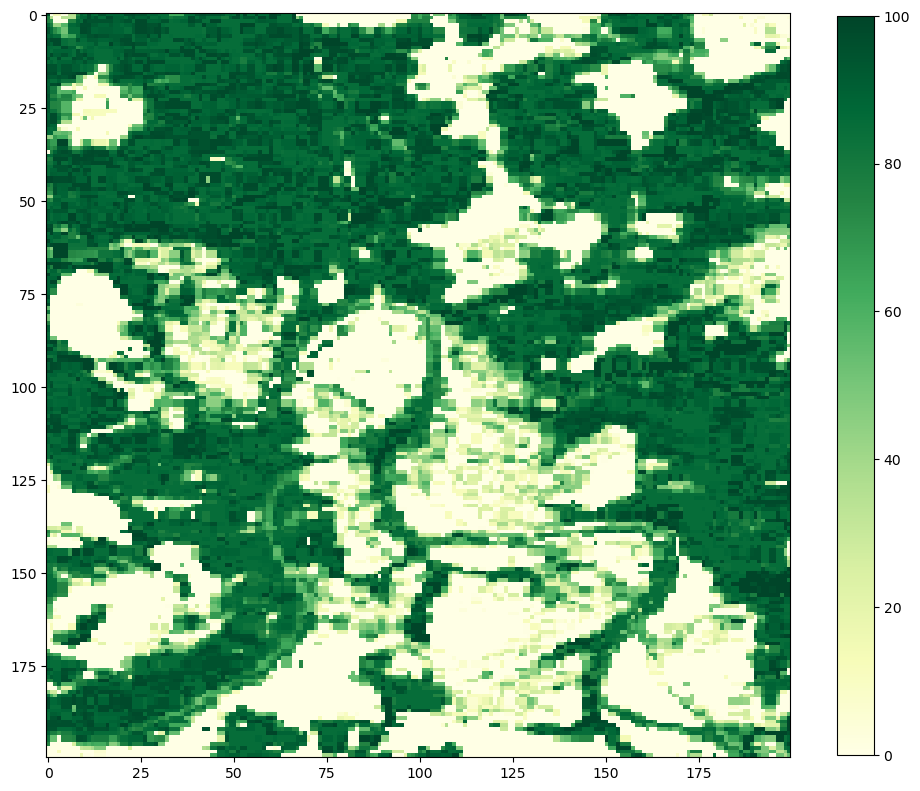

In [5]:
# plot the chosen region
plt.figure(figsize=(12, 12))
plt.imshow(data_tile[36675:36875, 30325:30525], cmap='YlGn') # format: y decreases from top to bottom
plt.colorbar(shrink=0.8)
plt.show()

## Extended Model Implementation

In [6]:
import numpy as np
import matplotlib.pyplot as plt

class OptimizedForestFireSimulator:
    def __init__(self, data_tiles, wind_speed=1.0, wind_direction=0, base_prob=0.3, 
                 burn_rate=0.2, rain_chance=0.05, rain_dampening=0.2):
        
        # normalize data
        self.density_grid = data_tiles.astype(float) / 100.0
        self.height, self.width = self.density_grid.shape

        self.wind_speed = wind_speed
        self.wind_direction = np.radians(wind_direction)
        self.base_prob = base_prob
        
        self.burn_rate = burn_rate
        self.rain_chance = rain_chance
        self.rain_dampening = rain_dampening
        
        self.step_counter = 0
        # wind vector (north=0, east=90)
        self.wind_vector = np.array([np.sin(self.wind_direction), np.cos(self.wind_direction)])

    def initialize(self, start_pos, headless=False):
        self.burning_mask = np.zeros((self.height, self.width), dtype=bool)
        self.burnt_mask = np.zeros((self.height, self.width), dtype=bool)
        self.fuel_grid = self.density_grid.copy()
        
        start_y, start_x = int(start_pos[0]), int(start_pos[1])
        if 0 <= start_y < self.height and 0 <= start_x < self.width:
             self.burning_mask[start_y, start_x] = True
        else:
            raise IndexError(f"Start position {start_pos} is out of bounds.")
        
        if not headless:
            self.figure, self.axes = plt.subplots()

    def _roll_and_pad(self, arr, shift):
        '''
        roll array and zero out wrapped edges
        shift is (dy, dx)
        '''
        result = np.roll(arr, shift=shift, axis=(0, 1))
        
        dy, dx = shift
        if dy > 0:
            result[:dy, :] = False # zero top rows if shifted down
        elif dy < 0:
            result[dy:, :] = False # zero bottom rows if shifted up
            
        if dx > 0:
            result[:, :dx] = False # zero left cols if shifted right
        elif dx < 0:
            result[:, dx:] = False # zero right cols if shifted left
            
        return result

    def update(self):
        # rain logic
        is_raining = np.random.random() < self.rain_chance
        current_spread_modifier = self.rain_dampening if is_raining else 1.0
        current_burn_rate = self.burn_rate * 2.0 if is_raining else self.burn_rate

        # fuel consumption (vectorized) - reduce fuel for all currently burning cells
        self.fuel_grid[self.burning_mask] -= current_burn_rate
        
        # identify cells that burnt out this turn
        burnt_out_mask = (self.fuel_grid <= 0) & self.burning_mask
        
        # update states for burnt out cells
        self.burning_mask[burnt_out_mask] = False
        self.burnt_mask[burnt_out_mask] = True
        self.fuel_grid[burnt_out_mask] = 0
        
        # fire spread (vectorized convolution-like approach)
        # only cells that still have fuel can spread fire
        active_fire_mask = self.burning_mask.copy()
        
        # accumulate new fires in this mask
        new_fires_mask = np.zeros((self.height, self.width), dtype=bool)
        
        # loop over 8 neighbors (dy, dx)
        # note: shift=(0, 1) means calculating spread from the left neighbor
        
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dy == 0 and dx == 0: continue
                
                # shift active fires to align with potential targets
                # shift=(dy, dx) moves data from (y-dy, x-dx) to (y, x)
                shifted_fire = self._roll_and_pad(active_fire_mask, shift=(dy, dx))
                
                # calculate wind factor for this direction
                # vector from source to target corresponds to shift (dy, dx)
                spread_vec = np.array([dx, dy]) 
                norm = np.linalg.norm(spread_vec)
                spread_vec = spread_vec / norm
                
                alignment = np.dot(self.wind_vector, spread_vec)
                wind_factor = np.tanh(alignment * self.wind_speed)
                
                # calculate probability grid: base * density * (1 + wind) * rain
                # density_grid is the density of the target cells at (y,x)
                prob_grid = (self.base_prob * self.density_grid * (1.0 + wind_factor) * current_spread_modifier)
                
                # random rolls for every cell for this direction
                random_grid = np.random.random((self.height, self.width))
                
                # ignition check: neighbor burning, roll passed, target not burning/burnt, has fuel
                ignition = (shifted_fire & 
                           (random_grid < prob_grid) & 
                           ~self.burning_mask & 
                           ~self.burnt_mask & 
                           (self.fuel_grid > 0))
                
                new_fires_mask |= ignition

        # apply new fires
        self.burning_mask |= new_fires_mask
        self.step_counter += 1
        
        # return intensity for stats
        return np.sum(self.burning_mask)

    def run_headless(self, max_steps=1000):
        while np.any(self.burning_mask) and self.step_counter < max_steps:
            self.update()
        return self.burnt_mask
    
    def observe(self):
            '''
            visualization: shows density as greyscale/green map
            overlays fire (red) and burnt areas (black/transparent)
            '''
            self.axes.clear()
            
            # underlying tree density (real data) using greens colormap
            self.axes.imshow(self.density_grid, cmap='Greens', vmin=0, vmax=1)
            
            # fire overlay - create rgba image for specific colors
            overlay = np.zeros((self.height, self.width, 4))
            
            # burnt areas black with alpha
            overlay[self.burnt_mask] = [0, 0, 0, 0.5] 
            
            # burning areas red (opaque)
            overlay[self.burning_mask] = [1, 0, 0, 1.0]
            
            self.axes.imshow(overlay)
            self.axes.set_title(f"Step: {self.step_counter}")
            
            # return axes object for animation
            return self.axes
    
    def run_headless_stats(self, max_steps=1000):
        '''runs simulation and returns (total burnt, duration, peak intensity)'''
        max_intensity = 0
        while np.any(self.burning_mask) and self.step_counter < max_steps:
            current_intensity = self.update()
            if current_intensity > max_intensity:
                max_intensity = current_intensity
        
        total_burnt = np.sum(self.burnt_mask)
        return total_burnt, self.step_counter, max_intensity

Starting strict convergence loop...
Goal: Max pixel change < 1.00% for 10 consecutive runs.
Run 110: Max Change = 0.0091 | Streak: 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩 (10/10)
✅ Converged at run 110!


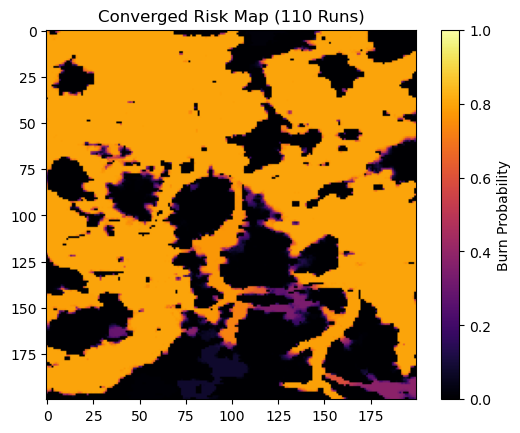

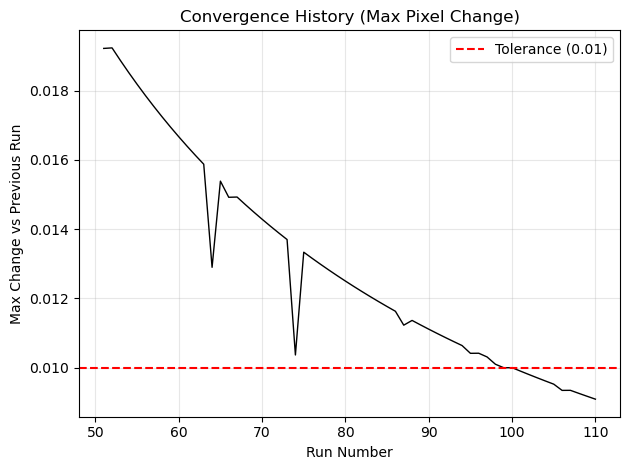

In [7]:
def fire_risk_map_strict_convergence(xvals, yvals, wind_speed, wind_direction, 
                                     base_prob=0.4, burn_rate=0.2, rain_chance=0.01, 
                                     tolerance=0.01, consecutive_needed=5, 
                                     min_runs=50, printout=False, history_plot=False, max_runs=500): 
    '''
    runs simulations until the risk map stabilizes
    
    convergence criteria:
    max change in any pixel's average probability must be less than 'tolerance' 
    for 'consecutive_needed' runs in a row
    '''
    plt.close('all')
    np.random.seed(99)
    
    # slice data
    grid_data = data_tile[xvals[0]:xvals[1], yvals[0]:yvals[1]] 
    valid_starts = np.argwhere(grid_data > 0)

    if len(valid_starts) == 0:
        print("Region is empty.")
        return np.zeros(grid_data.shape)

    # setup variables
    cumulative_burn_counts = np.zeros(grid_data.shape, dtype=float)
    prev_mean_map = np.zeros(grid_data.shape, dtype=float)
    
    consecutive_successes = 0
    history_max_change = []
    
    if printout:
        print(f"Starting strict convergence loop...")
        print(f"Goal: Max pixel change < {tolerance:.2%} for {consecutive_needed} consecutive runs.")
    
    # while loop with safety counter
    run_idx = 0
    while run_idx < max_runs:
        run_idx += 1
        
        # run single simulation
        random_index = np.random.randint(len(valid_starts))
        start_y, start_x = valid_starts[random_index]
        
        sim = OptimizedForestFireSimulator(
            grid_data, 
            wind_speed=wind_speed, 
            wind_direction=wind_direction, 
            base_prob=base_prob,
            burn_rate=burn_rate,     
            rain_chance=rain_chance, 
            rain_dampening=0.2       
        )
        sim.initialize(start_pos=(start_y, start_x), headless=True)
        final_burnt_mask = sim.run_headless(max_steps=500)
        
        # update statistics
        cumulative_burn_counts += final_burnt_mask.astype(float)
        current_mean_map = cumulative_burn_counts / run_idx
        
        # check convergence (skip first few runs to avoid division noise)
        if run_idx > min_runs:
            # calculate max change per pixel
            diff_map = np.abs(current_mean_map - prev_mean_map)
            max_change = np.max(diff_map)
            history_max_change.append(max_change)
            
            # check threshold
            if max_change < tolerance:
                consecutive_successes += 1
            else:
                consecutive_successes = 0 # reset if we spike above tolerance
            
            # formatting status bar
            if printout:
                bar = "🟩" * consecutive_successes + "⬜" * (consecutive_needed - consecutive_successes)
                sys.stdout.write(f"\rRun {run_idx}: Max Change = {max_change:.4f} | Streak: {bar} ({consecutive_successes}/{consecutive_needed})")
                sys.stdout.flush()
            
            if consecutive_successes >= consecutive_needed and printout:
                print(f"\n✅ Converged at run {run_idx}!")
                break
        else:
            # print progress for warm-up phase
            if run_idx % 10 == 0 and printout:
                sys.stdout.write(f"\rWarm-up Phase: Run {run_idx}/{min_runs}...")
                sys.stdout.flush()

        prev_mean_map = current_mean_map.copy()

    if run_idx >= max_runs and printout:
        print(f"\nWe hit max runs ({max_runs}) without strictly converging.")

    
    # plot the risk map
    im = plt.imshow(current_mean_map, cmap='inferno', vmin=0, vmax=1)
    plt.title(f"Converged Risk Map ({run_idx} Runs)")
    plt.colorbar(im, label="Burn Probability")
    plt.show()
    
    # plot convergence history
    if history_max_change and history_plot:
        plt.plot(range(min_runs + 1, run_idx + 1), history_max_change, color='black', linewidth=1)
        plt.axhline(y=tolerance, color='red', linestyle='--', label=f'Tolerance ({tolerance})')
        plt.title("Convergence History (Max Pixel Change)")
        plt.xlabel("Run Number")
        plt.ylabel("Max Change vs Previous Run")
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return current_mean_map

# run
xvals, yvals = (36675, 36875), (30325, 30525)

risk_map = fire_risk_map_strict_convergence(
    xvals, yvals, 
    wind_speed=0.5, 
    wind_direction=180, 
    tolerance=0.01,       # 1% max change
    consecutive_needed=10, # must hold for 5 runs
    min_runs=50,          # warmup
    printout=True,
    history_plot=True

)

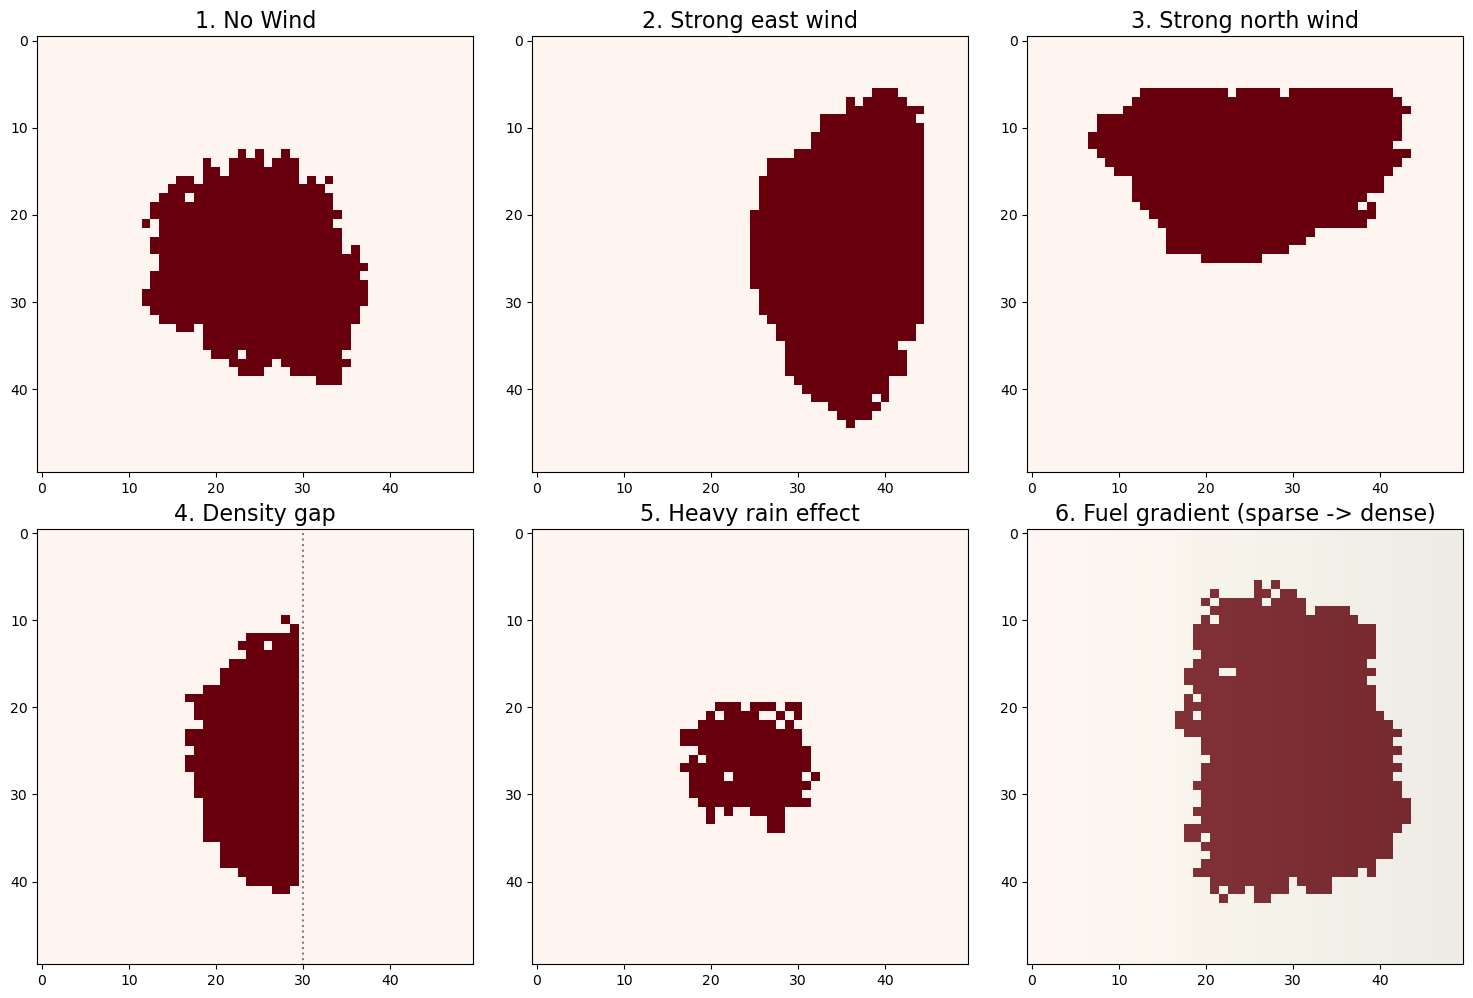

In [8]:
# helper to run and return result
def run_and_plot(test_name, grid, start_pos, params, max_steps=25):
    np.random.seed(111)
    # using the simulator class defined previously
    sim = OptimizedForestFireSimulator(
        grid, 
        wind_speed=params.get('wind_speed', 0),
        wind_direction=params.get('wind_direction', 0),
        base_prob=params.get('base_prob', 0.3)
    )
    
    sim.initialize(start_pos, headless=True)
    burnt_mask = sim.run_headless(max_steps)
    return burnt_mask

def run_test_suite():
    # synthetic 50x50 grid of density 100 (full forest)
    uniform_forest = np.ones((50, 50)) * 100
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    # test 1: isotropic spread (control)
    # expected: circular blob
    res1 = run_and_plot("no wind", uniform_forest, (25, 25), 
                        {'wind_speed': 0, 'base_prob': 0.3}, max_steps=20)
    axes[0].imshow(res1, cmap='Reds', vmin=0, vmax=1)
    axes[0].set_title("1. No Wind", fontsize=16)
    
    # test 2: wind direction (east)
    # expected: cone pointing right
    res2 = run_and_plot("east wind", uniform_forest, (25, 25), 
                        {'wind_speed': 100.0, 'wind_direction': 90, 'base_prob': 0.3}, max_steps=25)
    axes[1].imshow(res2, cmap='Reds', vmin=0, vmax=1)
    axes[1].set_title("2. Strong east wind", fontsize=16)

    # test 3: wind direction (south)
    # expected: cone pointing down
    res3 = run_and_plot("north wind", uniform_forest, (25, 25), 
                        {'wind_speed': 100, 'wind_direction': 180, 'base_prob': 0.3}, max_steps=25)
    axes[2].imshow(res3, cmap='Reds', vmin=0, vmax=1)
    axes[2].set_title("3. Strong north wind", fontsize=16)

    # test 4: density gap (firebreak)
    # expected: stops at x=30
    gap_forest = uniform_forest.copy()
    gap_forest[:, 30:31] = 0 
    
    res4 = run_and_plot("firebreak", gap_forest, (25, 25), {'wind_speed': 1, 'wind_direction': 90, 'base_prob': 0.3})
    
    axes[3].vlines(30, 0, 50, color='grey', linestyle='dotted')
    axes[3].imshow(res4, cmap='Reds')
    axes[3].set_title("4. Density gap", fontsize=16)

    # test 5: rain simulation (low prob)
    # expected: tiny/stunted fire
    res5 = run_and_plot("heavy rain", uniform_forest, (25, 25), 
                        {'wind_speed': 0, 'base_prob': 0.1}, max_steps=25) 
    axes[4].imshow(res5, cmap='Reds', vmin=0, vmax=1)
    axes[4].set_title("5. Heavy rain effect", fontsize=16)

    # test 6: fuel gradient (variable density)
    # expected: fire biases towards right (high density)
    gradient_forest = np.zeros((50, 50))
    for col in range(50):
        gradient_forest[:, col] = col * 2  # density 0 (left) to 100 (right)

    res6 = run_and_plot("fuel gradient", gradient_forest, (25, 25), 
                        {'wind_speed': 0, 'base_prob': 0.5}, max_steps=25) # higher prob to ensure spread
    
    # overlay density map (green) to show fuel
    axes[5].imshow(gradient_forest, cmap='Greens', alpha=0.3)
    axes[5].imshow(res6, cmap='Reds', alpha=0.8)
    axes[5].set_title("6. Fuel gradient (sparse -> dense)", fontsize=16)

    plt.tight_layout()
    plt.show()

# run the suite
run_test_suite()

Plotting with wind direction of 0 degrees.
Starting strict convergence loop...
Goal: Max pixel change < 1.00% for 5 consecutive runs.
Run 105: Max Change = 0.0095 | Streak: 🟩🟩🟩🟩🟩 (5/5)
✅ Converged at run 105!


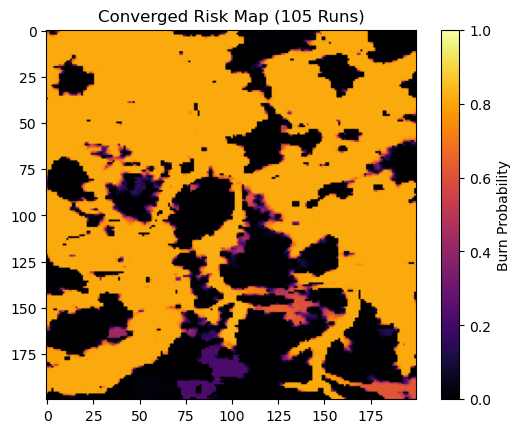

<Figure size 640x480 with 0 Axes>

Plotting with wind direction of 90 degrees.
Starting strict convergence loop...
Goal: Max pixel change < 1.00% for 5 consecutive runs.
Run 105: Max Change = 0.0095 | Streak: 🟩🟩🟩🟩🟩 (5/5)
✅ Converged at run 105!


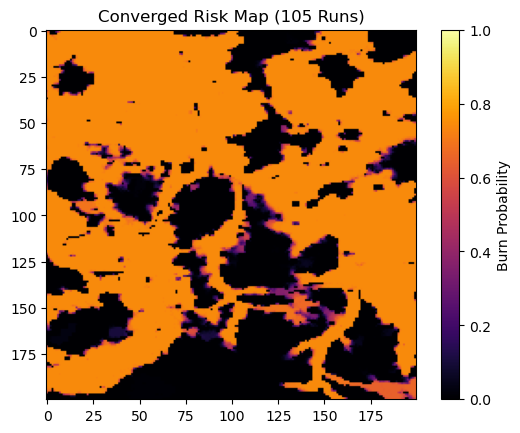

<Figure size 640x480 with 0 Axes>

Plotting with wind direction of 180 degrees.
Starting strict convergence loop...
Goal: Max pixel change < 1.00% for 5 consecutive runs.
Run 105: Max Change = 0.0095 | Streak: 🟩🟩🟩🟩🟩 (5/5)
✅ Converged at run 105!


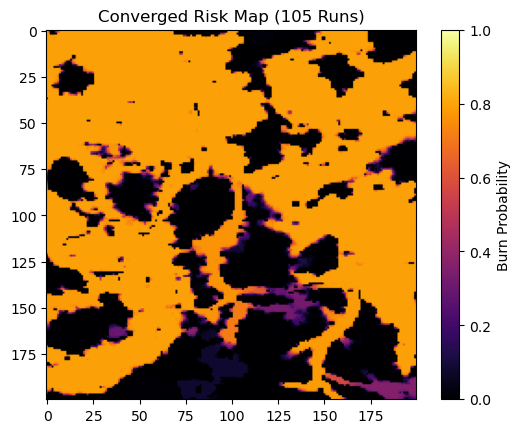

<Figure size 640x480 with 0 Axes>

Plotting with wind direction of 270 degrees.
Starting strict convergence loop...
Goal: Max pixel change < 1.00% for 5 consecutive runs.
Run 105: Max Change = 0.0095 | Streak: 🟩🟩🟩🟩🟩 (5/5)
✅ Converged at run 105!


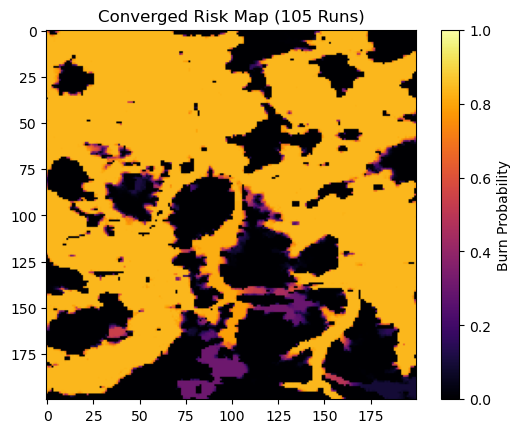

<Figure size 640x480 with 0 Axes>

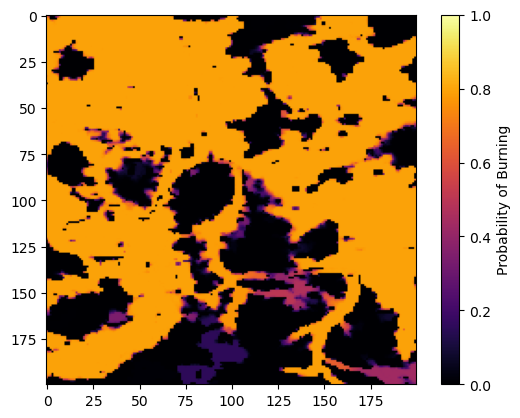

In [9]:
# run for differnet wind directions
xvals, yvals = (36675, 36875), (30325, 30525)
init_risk_map = np.zeros((xvals[1]-xvals[0], yvals[1]-yvals[0]), dtype=float)
n_runs = 50
wind_scenarios = [0, 90, 180, 270] # N, E, S, W
for wind_direction in wind_scenarios:
    print(f"Plotting with wind direction of {wind_direction} degrees.")
    curr_mask = fire_risk_map_strict_convergence(
                xvals, yvals, 
                wind_speed=0.5, 
                wind_direction=wind_direction, 
                tolerance=0.01,       # 0.01 max change
                consecutive_needed=5, # must hold for 5 runs
                min_runs=50,          # warmup
                printout=True,
                history_plot=False
            )
    init_risk_map += curr_mask.astype(float)
im2 = plt.imshow(init_risk_map / (len(wind_scenarios)), cmap='inferno', vmin=0, vmax=1)
plt.colorbar(im2, label="Probability of Burning")
plt.show()


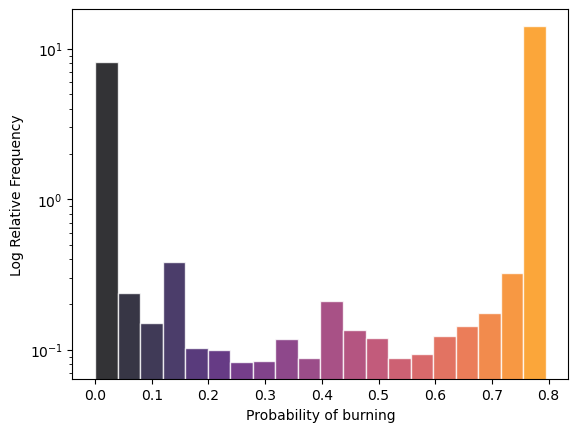

0.7574653068048821


In [10]:
# histogram over the fire risk map
list_copy = init_risk_map / 4
n, bins, patches = plt.hist(np.array(list_copy).flatten(), bins=20, density=True, edgecolor='white', alpha=0.8)

# give bins the same colors as on the plot
for bin_val, patch in zip(bins, patches):
    color = plt.cm.inferno(bin_val) 
    patch.set_facecolor(color)
plt.xlabel("Probability of burning")
plt.ylabel("Log Relative Frequency")
plt.yscale('log')
plt.show()

highrisk = sum(np.array(list_copy).flatten()>0.75)
total = sum(data_tile[36675:36875, 30325:30525].flatten() / 100 > 0)
print(highrisk/total)


In [11]:
def check_convergence(running_means, eps=0.01, window=5):
    """
    Returns True if the last `window` relative changes
    are all below eps.
    """
    # checking if we reached the number of consecutive successes
    if len(running_means) < window + 1:
        return False
    
    # extract the last 'window' elements
    recent = running_means[-(window+1):]
    
    # calculate the relative change
    rel_changes = [
        abs(recent[i+1] - recent[i]) / max(recent[i], 1e-8)
        for i in range(window)
    ]
    # check if the last 'window' runs were under the threshold
    return all(rc < eps for rc in rel_changes)


def run_sensitivity_analysis_with_convergence(
    xvals,
    yvals,
    param_name,
    param_values,
    max_runs=300,
    min_runs=30,
    eps=0.01,
    window=5,
    simulator_kwargs=None,
    seed=42
):
    # random seed
    np.random.seed(seed)

    # set the simulation parameters that are fixed or default otherwise
    simulator_kwargs = simulator_kwargs or {}

    # set up
    grid = data_tile[xvals[0]:xvals[1], yvals[0]:yvals[1]]
    valid_starts = np.argwhere(grid > 0)
    total_forest_cells = np.sum(grid > 0)

    # collect results on all variables including their CIs
    results = {
        "param": [],
        "burnt_mean": [], "burnt_ci": [],
        "duration_mean": [], "duration_ci": [],
        "intensity_mean": [], "intensity_ci": [],
        "runs_to_convergence": []
    }

    # iterate through the input lsit of parameter values
    for val in param_values:
        burnt_vals = []
        duration_vals = []
        intensity_vals = []
        running_means = []

        # run simulation until values
        for run in range(max_runs):
            start_y, start_x = valid_starts[np.random.randint(len(valid_starts))]

            sim = OptimizedForestFireSimulator(
                grid,
                **simulator_kwargs,
                **{param_name: val}
            )
            sim.initialize((start_y, start_x), headless=True)

            burnt, duration, intensity = sim.run_headless_stats(max_steps=1000)

            burnt_vals.append(burnt / total_forest_cells)
            duration_vals.append(duration)
            intensity_vals.append(intensity)

            running_means.append(np.mean(burnt_vals))

            if run + 1 >= min_runs and check_convergence(running_means, eps, window):
                break

        def mean_ci(data):
            mean = np.mean(data)
            if len(data) > 1:
                sem = sts.sem(data)
                h = sem * sts.t.ppf(0.975, len(data)-1)
            else:
                h = 0
            return mean, h

        b_mean, b_ci = mean_ci(burnt_vals)
        d_mean, d_ci = mean_ci(duration_vals)
        i_mean, i_ci = mean_ci(intensity_vals)

        results["param"].append(val)
        results["burnt_mean"].append(b_mean)
        results["burnt_ci"].append(b_ci)
        results["duration_mean"].append(d_mean)
        results["duration_ci"].append(d_ci)
        results["intensity_mean"].append(i_mean)
        results["intensity_ci"].append(i_ci)
        results["runs_to_convergence"].append(len(burnt_vals))

    return results


def plot_sensitivity(results, param_label):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Burnt fraction
    axes[0].errorbar(
        results["param"],
        results["burnt_mean"],
        yerr=results["burnt_ci"],
        fmt='-o',
        capsize=4
    )
    axes[0].set_title("Fraction Burnt vs " + param_label)
    axes[0].set_xlabel(param_label)
    axes[0].set_ylabel("Fraction of Forest Burnt")
    axes[0].grid(alpha=0.3)

    # Duration
    axes[1].errorbar(
        results["param"],
        results["duration_mean"],
        yerr=results["duration_ci"],
        fmt='-o',
        capsize=4
    )
    axes[1].set_title("Fire Duration vs " + param_label)
    axes[1].set_xlabel(param_label)
    axes[1].set_ylabel("Duration (steps)")
    axes[1].grid(alpha=0.3)

    # Intensity
    axes[2].errorbar(
        results["param"],
        results["intensity_mean"],
        yerr=results["intensity_ci"],
        fmt='-o',
        capsize=4
    )
    axes[2].set_title("Peak Intensity vs " + param_label)
    axes[2].set_xlabel(param_label)
    axes[2].set_ylabel("Max Burning Cells")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


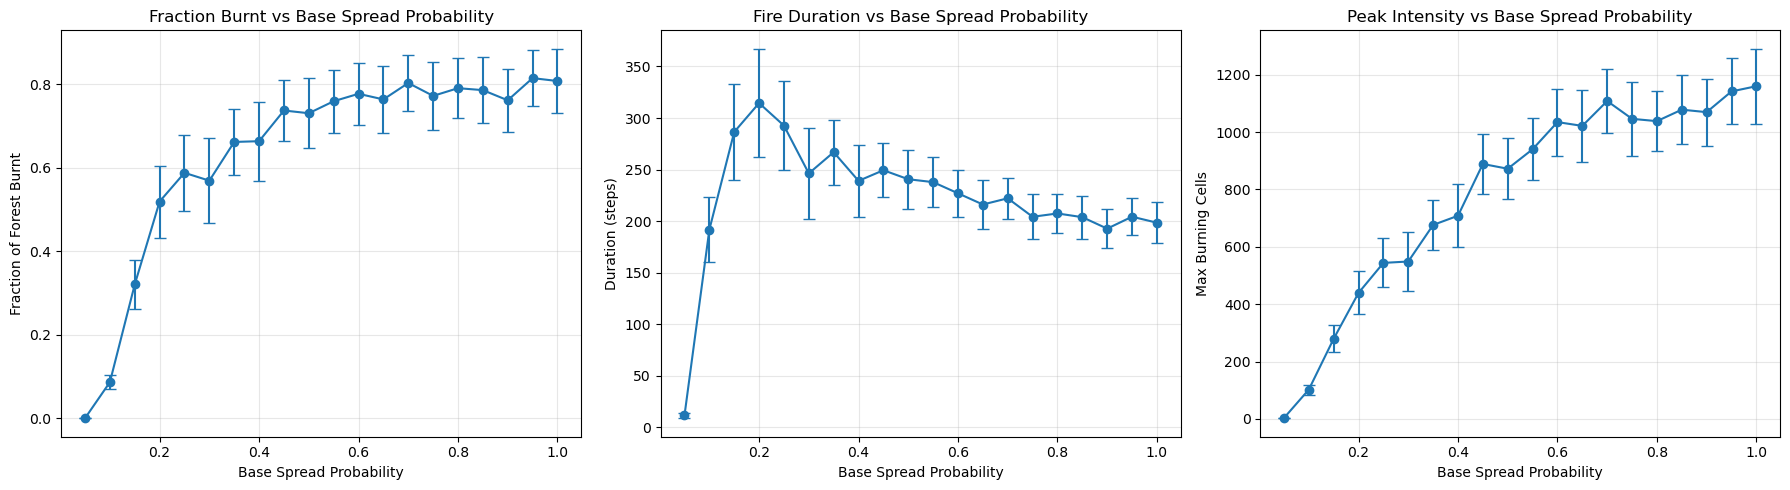

In [12]:
prob_values = np.linspace(0.05, 1, 20)
xvals, yvals = (36675, 36875), (30325, 30525)

results = run_sensitivity_analysis_with_convergence(
    xvals,
    yvals,
    param_name="base_prob",
    param_values=prob_values,
    min_runs=50,
    simulator_kwargs=dict(
        wind_speed=0.0,
        burn_rate=0.2,
        rain_chance=0.01
    )
)

plot_sensitivity(results, "Base Spread Probability")


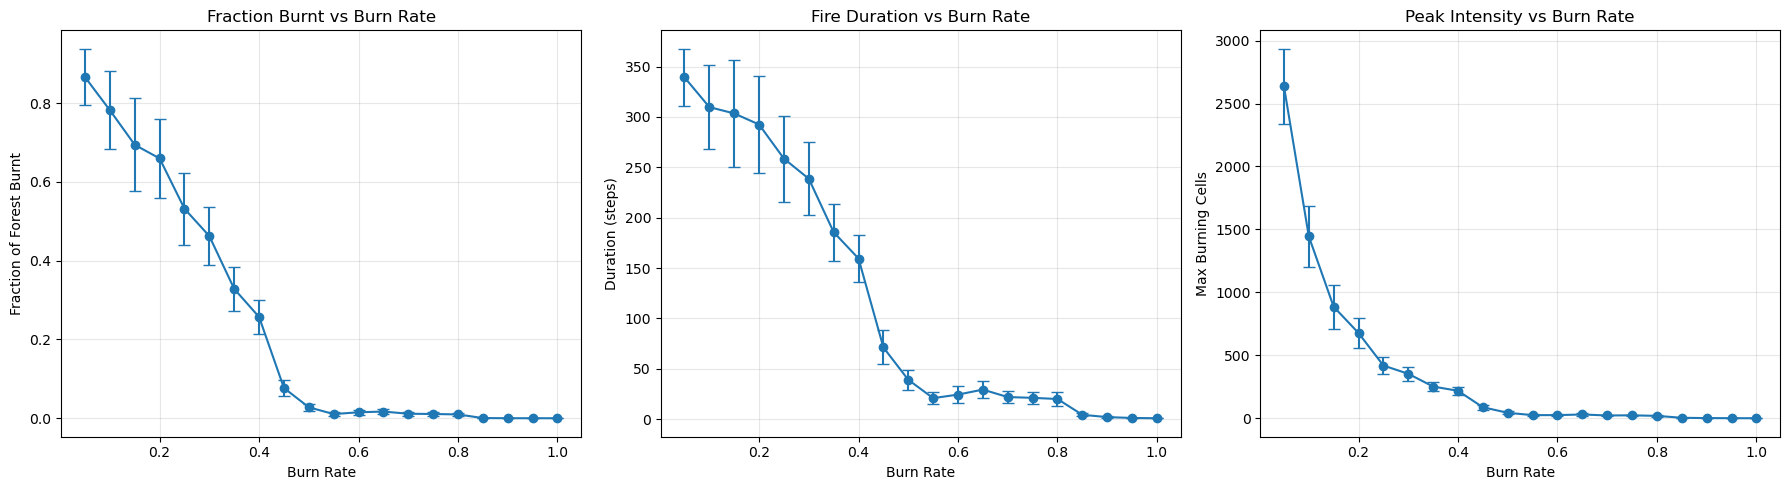

In [13]:
prob_values = np.linspace(0.05, 1, 20)
xvals, yvals = (36675, 36875), (30325, 30525)

results = run_sensitivity_analysis_with_convergence(
    xvals,
    yvals,
    param_name="burn_rate",
    param_values=prob_values,
    simulator_kwargs=dict(
        wind_speed=0.0,
        base_prob=0.3,
        rain_chance=0.01
    )
)

plot_sensitivity(results, "Burn Rate")

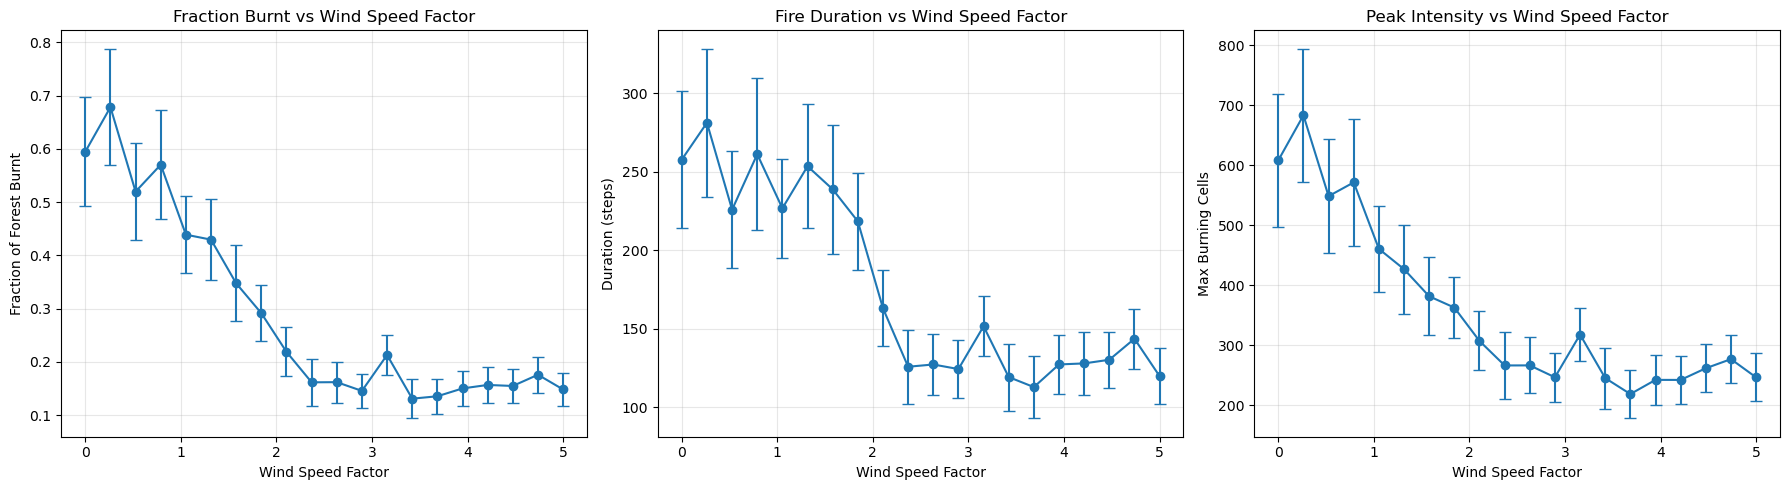

In [14]:
prob_values = np.linspace(0,5, 20)
xvals, yvals = (36675, 36875), (30325, 30525)

results = run_sensitivity_analysis_with_convergence(
    xvals,
    yvals,
    param_name="wind_speed",
    param_values=prob_values,
    simulator_kwargs=dict(
        burn_rate=0.2,
        base_prob=0.3,
        rain_chance=0.01
    )
)

plot_sensitivity(results, "Wind Speed Factor")

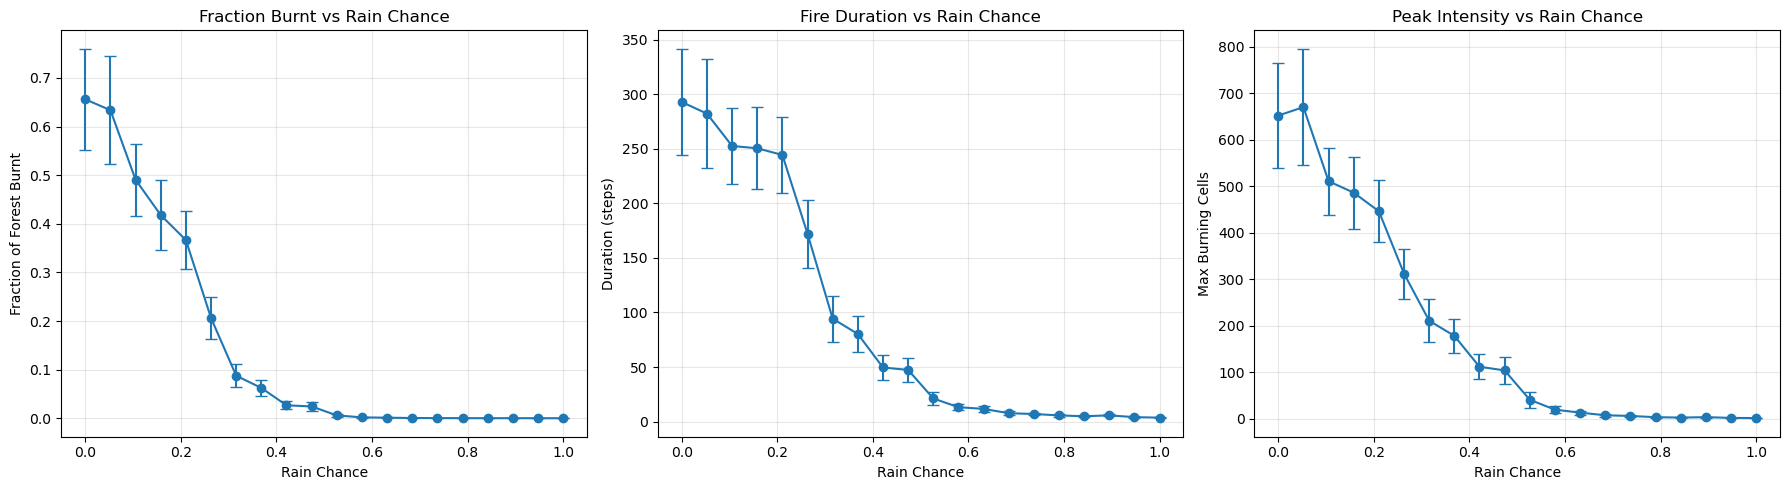

In [15]:
prob_values = np.linspace(0,1,20)
xvals, yvals = (36675, 36875), (30325, 30525)

results = run_sensitivity_analysis_with_convergence(
    xvals,
    yvals,
    param_name="rain_chance",
    param_values=prob_values,
    simulator_kwargs=dict(
        burn_rate=0.2,
        base_prob=0.3,
        wind_speed=0
    )
)

plot_sensitivity(results, "Rain Chance")

## USING NETWORK THEORY TO IDENTIFY IMPORTANT CELLS

Slicing data from 36675:36875, 30325:30525
Generating 50 fixed test scenarios...
Measuring baseline risk...
Baseline: 15123.22 ± 3130.08
Starting optimization (Stopping if improvement < 0.5% of baseline)...

Iteration 1/10
Blocked 10 nodes. New Risk: 14901.86 ± 3107.68

Iteration 2/10
Blocked 10 nodes. New Risk: 14436.12 ± 3073.16

Iteration 3/10
Blocked 10 nodes. New Risk: 12551.74 ± 2907.35

Iteration 4/10
Blocked 10 nodes. New Risk: 9520.88 ± 2138.64

Iteration 5/10
Blocked 10 nodes. New Risk: 8852.94 ± 1895.64

Iteration 6/10
Blocked 10 nodes. New Risk: 8335.12 ± 1688.98

Iteration 7/10
Blocked 10 nodes. New Risk: 8293.92 ± 1678.15
Converged! Improvement (41.20) is below tolerance threshold.


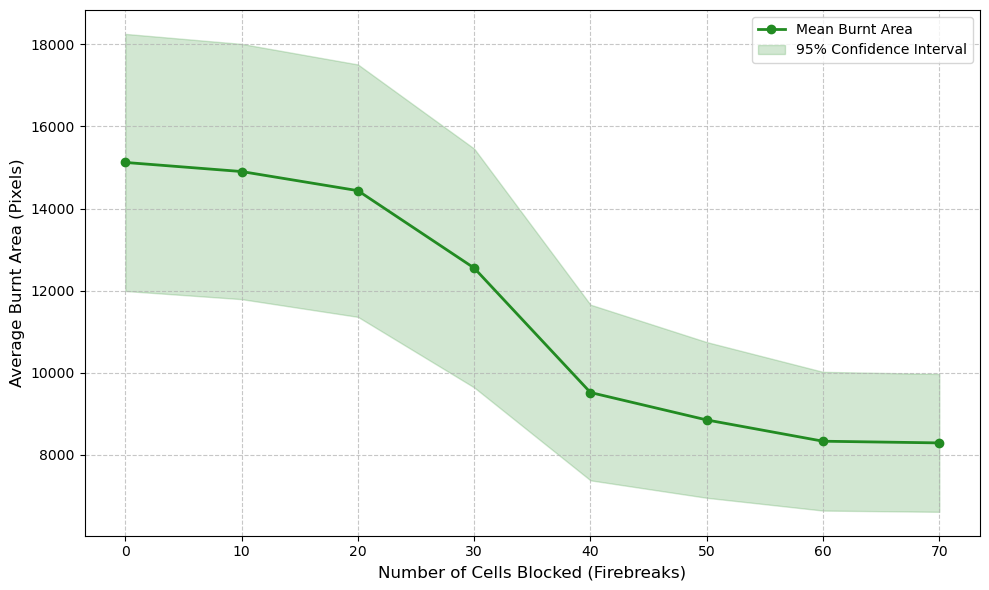

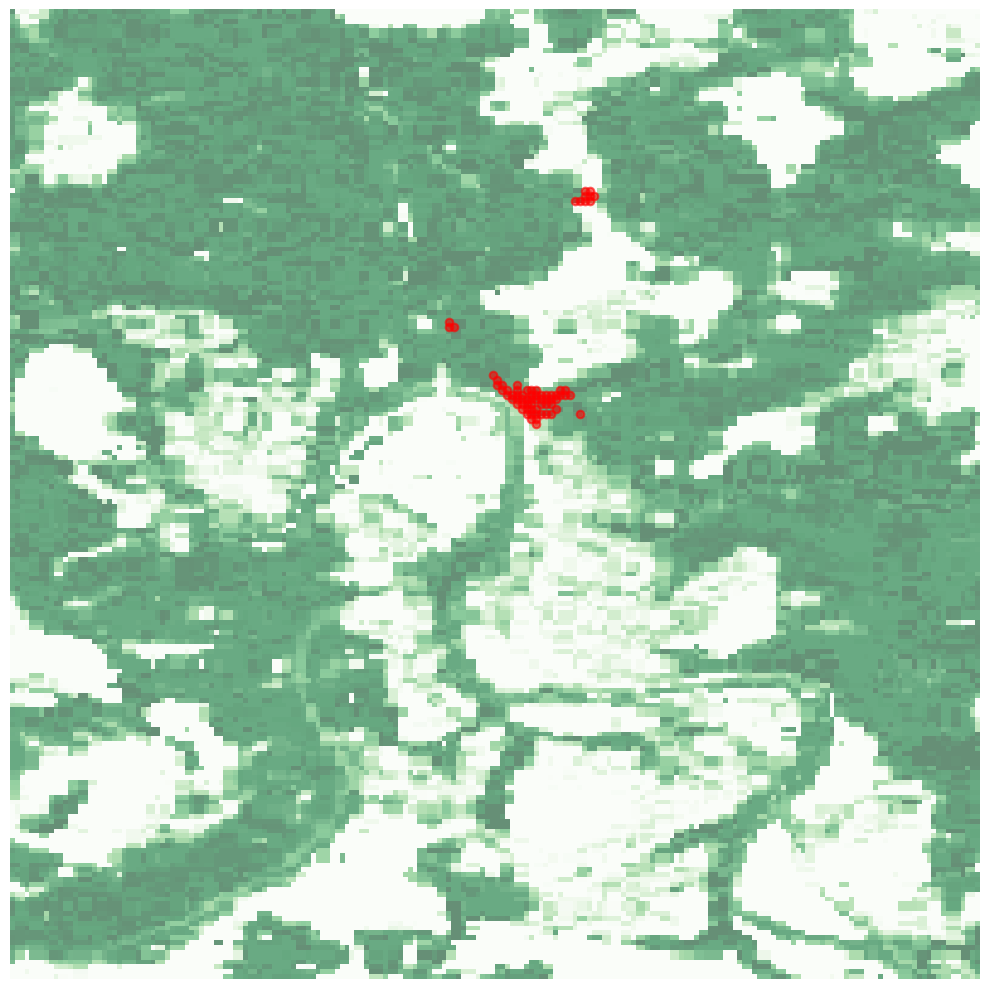

In [17]:
# helper functions for graph analysis and centrality
def build_fire_graph_vectorized(density_grid, wind_speed, wind_direction, base_prob):
    # builds the graph using matrix operations instead of loops
    # initialize a directed graph object
    G = nx.DiGraph()
    # get dimensions of the grid
    height, width = density_grid.shape
    # convert wind direction to radians for vector math
    wind_rad = np.radians(wind_direction)
    # create the wind vector components
    wind_vector = np.array([np.sin(wind_rad), np.cos(wind_rad)])
    
    # find indices where trees exist
    y_idxs, x_idxs = np.nonzero(density_grid > 0)
    # add these locations as nodes in the graph
    for y, x in zip(y_idxs, x_idxs):
        G.add_node((y, x))
    
    # iterate over all possible neighbors including diagonals
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            # skip the center cell itself
            if dy == 0 and dx == 0: continue
            
            # shift grid to align neighbors for vectorized calculation
            neighbor_density = np.roll(density_grid, shift=(dy, dx), axis=(0, 1))
            # create mask for valid edges between existing trees
            valid_edge_mask = (neighbor_density > 0) & (density_grid > 0)
            
            # handle boundary conditions to avoid wrapping around edges
            if dy > 0: valid_edge_mask[:dy, :] = False
            elif dy < 0: valid_edge_mask[dy:, :] = False
            if dx > 0: valid_edge_mask[:, :dx] = False
            elif dx < 0: valid_edge_mask[:, dx:] = False
            
            # define the vector of fire spread direction
            spread_vec = np.array([dx, dy])
            # normalize the spread vector
            spread_vec = spread_vec / np.linalg.norm(spread_vec)
            # calculate alignment with wind direction
            alignment = np.dot(wind_vector, spread_vec)
            # calculate wind modifier based on alignment
            modifier = np.exp(alignment * wind_speed)
            
            # calculate probability of spread for the entire grid
            prob_grid = base_prob * neighbor_density * density_grid * modifier
            # clip probabilities to avoid mathematical errors in logs
            prob_grid = np.clip(prob_grid, 1e-6, 0.999) 
            # convert probability to weight using negative log likelihood
            weight_grid = -np.log(prob_grid)
            
            # get coordinates of valid edges
            target_ys, target_xs = np.nonzero(valid_edge_mask)
            # skip if no valid edges found for this direction
            if len(target_ys) == 0: continue
            
            # calculate source coordinates based on shift
            source_ys = target_ys - dy
            source_xs = target_xs - dx
            # extract weights for these edges
            weights = weight_grid[target_ys, target_xs]
            
            # prepare list of edges to add to graph
            edges_to_add = []
            for i in range(len(target_ys)):
                # append tuple of source target and weight
                edges_to_add.append(((source_ys[i], source_xs[i]), (target_ys[i], target_xs[i]), weights[i]))
            
            # add all edges to graph at once
            G.add_weighted_edges_from(edges_to_add)
            
    return G

def find_bottlenecks_fast(G, k_approx=100, top_n=20):
    # return empty list if graph is empty
    if len(G) == 0: return []
    # limit k to graph size to avoid errors
    k_safe = min(len(G), k_approx)
    # calculate betweenness centrality with approximation k
    centrality = nx.betweenness_centrality(G, weight='weight', normalized=True, k=k_safe, seed=42)
    # sort nodes by centrality score descending
    sorted_nodes = sorted(centrality.items(), key=lambda item: item[1], reverse=True)
    # return the top n nodes
    return sorted_nodes[:top_n]


# robust risk measurement with confidence intervals
def measure_risk_stats(grid, fixed_scenarios):
    # returns mean area and confidence interval margin
    areas = []
    
    # iterate through pre generated scenarios
    for (sy, sx, seed) in fixed_scenarios:
        # if start cell is empty skip simulation
        if grid[sy, sx] == 0:
            areas.append(0) 
            continue
            
        # set random seed for reproducibility
        np.random.seed(seed)
        
        # initialize simulator with current grid
        sim = OptimizedForestFireSimulator(
            grid * 100, 
            wind_speed=0.5, 
            base_prob=0.3
        )
        
        try:
            # setup fire at start location
            sim.initialize((sy, sx), headless=True)
            # run simulation to completion
            burnt = sim.run_headless(max_steps=500)
            # record total burnt area
            areas.append(np.sum(burnt))
        except IndexError:
            # handle potential boundary errors gracefully
            areas.append(0)
    
    # calculate mean of burnt areas
    mean_val = np.mean(areas)
    # check if we have enough data for statistics
    if len(areas) > 1:
        # calculate standard error of the mean
        sem = sts.sem(areas)
        # calculate ninety five percent confidence interval
        h = sem * sts.t.ppf((1 + 0.95) / 2., len(areas)-1)
    else:
        # set margin to zero if single sample
        h = 0
        
    return mean_val, h

# optimization loop with convergence check
def optimize_firebreaks_robust(initial_grid, step_size=5, max_steps=10, n_scenarios=50, improvement_tolerance=0.005):
    # create copy of grid to modify
    current_grid = initial_grid.copy()
    # initialize history dictionary for plotting
    history = {'removed_count': [], 'avg_burnt': [], 'ci_margin': []}
    
    # generate fixed scenarios
    print(f"Generating {n_scenarios} fixed test scenarios...")
    # identify all valid start locations
    valid_starts = np.argwhere(initial_grid > 0)
    # list to store scenario parameters
    fixed_scenarios = []
    
    # create n fixed scenarios
    for _ in range(n_scenarios):
        # pick random index for start location
        idx = np.random.randint(len(valid_starts))
        sy, sx = valid_starts[idx]
        # generate random seed for this run
        run_seed = np.random.randint(0, 999999)
        # store parameters tuple
        fixed_scenarios.append((sy, sx, run_seed))

    # measure baseline risk
    print("Measuring baseline risk...")
    # run simulations on initial grid
    base_mean, base_ci = measure_risk_stats(current_grid, fixed_scenarios)
    # record baseline stats
    history['removed_count'].append(0)
    history['avg_burnt'].append(base_mean)
    history['ci_margin'].append(base_ci)
    print(f"Baseline: {base_mean:.2f} ± {base_ci:.2f}")
    
    # track total removed cells
    total_removed = 0
    # track previous risk for convergence check
    prev_risk = base_mean
    
    print(f"Starting optimization (Stopping if improvement < {improvement_tolerance:.1%} of baseline)...")

    # main optimization loop
    for step in range(max_steps):
        print(f"\nIteration {step+1}/{max_steps}")
        
        # build graph from current grid state
        G = build_fire_graph_vectorized(current_grid, wind_speed=0.5, wind_direction=180, base_prob=0.3)
        
        # calculate centrality and find bottlenecks
        top_bottlenecks = find_bottlenecks_fast(G, k_approx=200, top_n=step_size)
        
        # stop if no bottlenecks found
        if not top_bottlenecks:
            print("No more bottlenecks found!")
            break

        # extract node coordinates
        nodes_to_remove = [node for node, score in top_bottlenecks]
        # remove nodes from grid
        for (y, x) in nodes_to_remove:
            current_grid[y, x] = 0.0
            
        # update total count
        total_removed += step_size
        
        # measure new risk after removal
        new_mean, new_ci = measure_risk_stats(current_grid, fixed_scenarios)
        
        # update history
        history['removed_count'].append(total_removed)
        history['avg_burnt'].append(new_mean)
        history['ci_margin'].append(new_ci)
        
        # calculate improvement
        diff = prev_risk - new_mean
        print(f"Blocked {len(nodes_to_remove)} nodes. New Risk: {new_mean:.2f} ± {new_ci:.2f}")
        
        # check convergence condition
        # stop if improvement is negligible compared to baseline
        if diff < (base_mean * improvement_tolerance):
            print(f"Converged! Improvement ({diff:.2f}) is below tolerance threshold.")
            break
            
        # update previous risk
        prev_risk = new_mean

    return history, current_grid


# execute optimization
y_start, y_end = 36675, 36875
x_start, x_end = 30325, 30525

print(f"Slicing data from {y_start}:{y_end}, {x_start}:{x_end}")
# slice and normalize data tile
sub_density = data_tile[y_start:y_end, x_start:x_end].astype(float) / 100.0

# check if slice is empty
if np.sum(sub_density) == 0:
    print("WARNING: Selected slice is empty! Change coordinates.")
else:
    # run optimization function
    stats_data, final_grid = optimize_firebreaks_robust(
        sub_density, 
        step_size=10,   
        max_steps=10,
        n_scenarios=50,
        improvement_tolerance=0.005 
    )

    # plotting results
    # identify firebreak locations
    firebreaks_mask = (sub_density > 0) & (final_grid == 0)
    # get coordinates of breaks
    y_breaks, x_breaks = np.nonzero(firebreaks_mask)

    # plot 1 effectiveness curve with confidence intervals
    plt.figure(figsize=(10, 6))
    
    # extract data for plotting
    x_vals = np.array(stats_data['removed_count'])
    y_vals = np.array(stats_data['avg_burnt'])
    ci_vals = np.array(stats_data['ci_margin'])
    
    # plot mean trend line
    plt.plot(x_vals, y_vals, marker='o', linewidth=2, color='forestgreen', label='Mean Burnt Area')
    
    # fill area for confidence interval
    plt.fill_between(x_vals, y_vals - ci_vals, y_vals + ci_vals, color='forestgreen', alpha=0.2, label='95% Confidence Interval')
    
    # set plot titles and labels
    plt.xlabel("Number of Cells Blocked (Firebreaks)", fontsize=12)
    plt.ylabel("Average Burnt Area (Pixels)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # plot 3 red markers on map
    plt.figure(figsize=(10, 10))
    # show original density map slightly transparent
    plt.imshow(sub_density, cmap='Greens', vmin=0, vmax=1, alpha=0.6)
    # scatter plot red dots at break locations
    plt.scatter(x_breaks, y_breaks, c='red', marker='o', s=30, alpha=0.6, linewidths=1.5)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Slicing data from 36675:36875, 30325:30525
Building Graph...
Calculating Centrality (this may take a moment)...


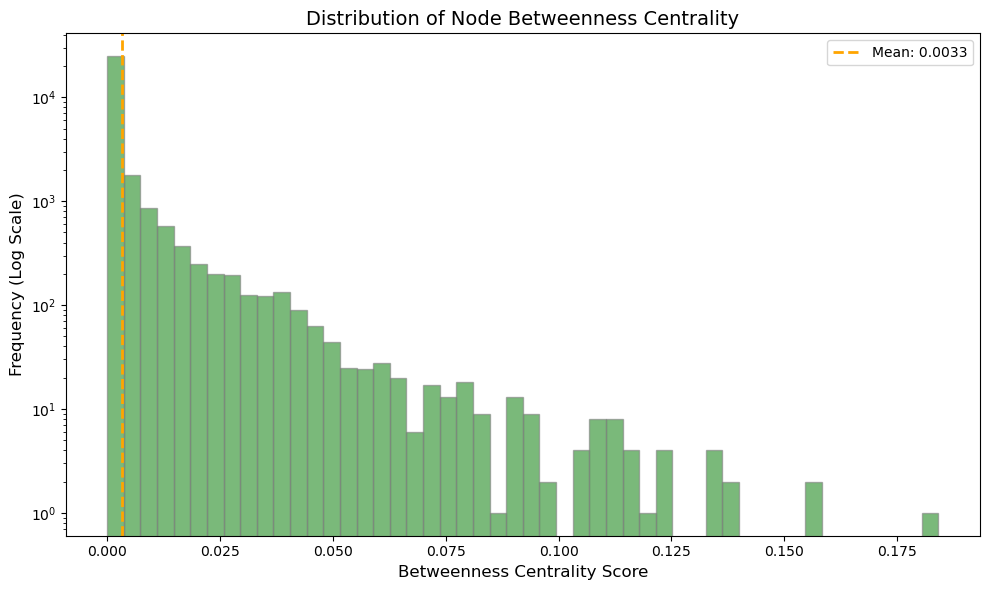

In [18]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt


y_start, y_end = 36675, 36875
x_start, x_end = 30325, 30525

print(f"Slicing data from {y_start}:{y_end}, {x_start}:{x_end}")
sub_density = data_tile[y_start:y_end, x_start:x_end].astype(float) / 100.0


# 1. Build the Graph (Using your existing density grid)
# Ensure 'sub_density' is defined (e.g. your 100x100 slice)
print("Building Graph...")
G = build_fire_graph_vectorized(sub_density, wind_speed=0.5, wind_direction=180, base_prob=0.3)

# 2. Calculate Centrality
# We calculate it for ALL nodes. 
# Note: On a large grid, calculating exact centrality is slow. 
# We use 'k=None' for exact (slow) or 'k=500' for approximation (fast).
print("Calculating Centrality (this may take a moment)...")
centrality_dict = nx.betweenness_centrality(G, weight='weight', normalized=True, k=500, seed=42)

# Extract just the values (scores)
centrality_values = list(centrality_dict.values())

# 3. Plot Histogram
plt.figure(figsize=(10, 6))

# We use 'log=True' because usually there are MANY low-value nodes and FEW high-value nodes.
plt.hist(centrality_values, bins=50, color='forestgreen', alpha=0.6, edgecolor='grey', log=True)

plt.title("Distribution of Node Betweenness Centrality", fontsize=14)
plt.xlabel("Betweenness Centrality Score", fontsize=12)
plt.ylabel("Frequency (Log Scale)", fontsize=12)

# Add a vertical line for the mean
mean_val = np.mean(centrality_values)
plt.axvline(mean_val, color='orange', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.4f}')

plt.legend()
plt.tight_layout()
plt.show()


RUNNING WITH REDUCED PLOTS
Uniform Mode: Thinning all cells equally.
Running Experiment on (200, 200) grid...

Factor 1.00: Runs 107 | Mean: 15136.9 | Change: 0.46% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.95: Runs 67 | Mean: 15240.8 | Change: 0.14% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.90: Runs 109 | Mean: 12809.4 | Change: 0.38% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.85: Runs 105 | Mean: 10658.2 | Change: 0.23% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.80: Runs 109 | Mean: 9272.5 | Change: 0.66% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.75: Runs 118 | Mean: 7028.5 | Change: 0.85% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.70: Runs 164 | Mean: 2604.4 | Change: 0.61% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.65: Runs 124 | Mean: 1057.0 | Change: 0.16% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.60: Runs 108 | Mean: 160.2 | Change: 0.89% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.55: Runs 147 | Mean: 148.5 | Change: 0.04% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.50: Runs 122 | Mean: 29.6 | Change: 0.79% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.45: Runs 104 | Mean: 7.9 | Change: 0.84% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.40: Runs 99 | Mean: 3.1 | Change: 0.69% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.35: Runs 131 | Mean: 1.9 | Ch

/var/folders/fk/kjxgps_j56lbz4tvr6tr8ss40000gn/T/ipykernel_40874/3937540932.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


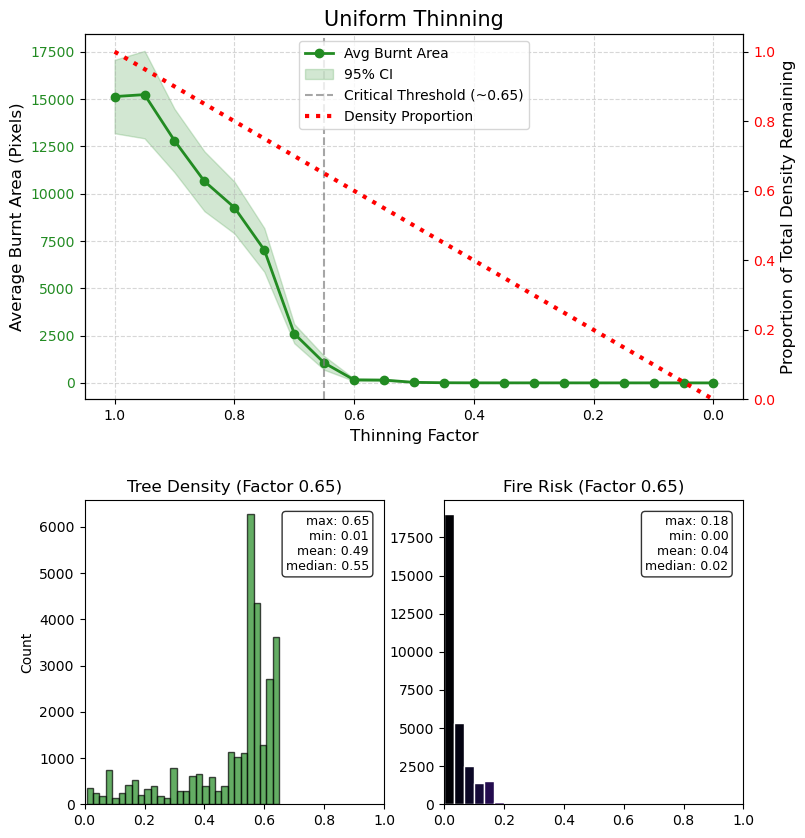

(array([1.  , 0.95, 0.9 , 0.85, 0.8 , 0.75, 0.7 , 0.65, 0.6 , 0.55, 0.5 ,
        0.45, 0.4 , 0.35, 0.3 , 0.25, 0.2 , 0.15, 0.1 , 0.05, 0.  ]),
 array([1.51368505e+04, 1.52407612e+04, 1.28094404e+04, 1.06582095e+04,
        9.27253211e+03, 7.02847458e+03, 2.60435976e+03, 1.05704032e+03,
        1.60157407e+02, 1.48476190e+02, 2.96147541e+01, 7.90384615e+00,
        3.10101010e+00, 1.91603053e+00, 1.96666667e+00, 1.45714286e+00,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        0.00000000e+00]),
 array([1.94052814e+03, 2.31193662e+03, 1.67931961e+03, 1.58019277e+03,
        1.36949931e+03, 1.15620587e+03, 5.08733573e+02, 3.62773036e+02,
        6.48133464e+01, 5.41967887e+01, 1.33298777e+01, 3.20478998e+00,
        7.30591397e-01, 2.92427696e-01, 5.76592348e-01, 2.58936589e-01,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00]))

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import tqdm
import sys

def run_converging_thinning_experiment(base_grid, wind_speed=0.5, wind_direction=180, 
                                       strategy='uniform', # uniform or targeted
                                       tolerance=0.01,      
                                       consecutive_needed=10, 
                                       min_runs=50, 
                                       max_runs=500):
    
    # setup thinning factors from 1.0 down to 0.0
    factors = np.linspace(1.0, 0.0, 21)
    
    means = []
    cis = []
    
    # track remaining biomass proportion
    remaining_density_props = [] 
    initial_total_density = np.sum(base_grid)

    # store maps for histograms
    history_maps = {} 
    
    # pre calculate median for targeted strategy
    density_threshold = 0
    if strategy == 'targeted':
        valid_pixels = base_grid[base_grid > 0]
        density_threshold = np.median(valid_pixels)
        print(f"Targeted Mode: Thinning only cells with density > {density_threshold:.2f}")
    else:
        print(f"Uniform Mode: Thinning all cells equally.")

    print(f"Running Experiment on {base_grid.shape} grid...")
    
    # loop over factors
    for f in factors:
        # apply thinning strategy
        current_grid = base_grid.copy()
        
        if strategy == 'targeted':
            high_density_mask = current_grid > density_threshold
            current_grid[high_density_mask] *= f
        else:
            current_grid *= f
            
        # calculate remaining proportion for this factor
        current_total_density = np.sum(current_grid)
        # avoid division by zero if grid is empty
        if initial_total_density > 0:
            prop = current_total_density / initial_total_density
        else:
            prop = 0
        remaining_density_props.append(prop)
            
        valid_starts = np.argwhere(current_grid > 0)
        
        if len(valid_starts) == 0:
            means.append(0)
            cis.append(0)
            # store empty map data to avoid errors later
            history_maps[f] = {'risk': np.zeros(base_grid.shape), 'density': current_grid}
            continue
            
        # converging simulation loop
        burnt_areas = []
        cumulative_burn_mask = np.zeros(base_grid.shape) # track pixel burns
        
        prev_mean = 0
        streak = 0
        run_count = 0
        
        sys.stdout.write(f"\nFactor {f:.2f}: ")
        
        while run_count < max_runs:
            # run sim
            idx = np.random.randint(len(valid_starts))
            start_pos = valid_starts[idx]
            
            sim = OptimizedForestFireSimulator(
                current_grid * 100, 
                wind_speed=wind_speed, 
                wind_direction=wind_direction, 
                base_prob=0.3
            )
            sim.initialize(start_pos, headless=True)
            mask = sim.run_headless(max_steps=500)
            
            # update stats
            burnt_areas.append(np.sum(mask))
            cumulative_burn_mask += mask # add to risk map
            run_count += 1
            
            # check convergence
            if run_count >= min_runs:
                current_mean = np.mean(burnt_areas)
                
                if prev_mean > 0:
                    rel_change = abs(current_mean - prev_mean) / prev_mean
                else:
                    rel_change = 0 if current_mean == 0 else 1.0
                
                if rel_change < tolerance:
                    streak += 1
                else:
                    streak = 0
                
                prev_mean = current_mean
                
                status = "🟩" * streak + "⬜" * (consecutive_needed - streak)
                sys.stdout.write(f"\rFactor {f:.2f}: Runs {run_count} | Mean: {current_mean:.1f} | Change: {rel_change:.2%} | {status}")
                sys.stdout.flush()
                
                if streak >= consecutive_needed:
                    break
        
        # store stats and maps
        avg_burn = np.mean(burnt_areas)
        sem = stats.sem(burnt_areas)
        margin = sem * stats.t.ppf((1 + 0.95) / 2., len(burnt_areas)-1)
        
        means.append(avg_burn)
        cis.append(margin)
        
        # save the risk map and density map used
        history_maps[f] = {
            'risk': cumulative_burn_mask / run_count,
            'density': current_grid
        }

    # setup main figure with gridspec for custom layout
    # row 0 is the line graph
    # row 1 is histograms for threshold factor ONLY
    fig = plt.figure(figsize=(8.5, 10)) # Reduced height since we removed one row
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1], hspace=0.3)
    
    # --- plot 1 line graph top row ---
    means = np.array(means)
    cis = np.array(cis)
    remaining_density_props = np.array(remaining_density_props)
    
    ax1 = fig.add_subplot(gs[0, :]) # spans both columns
    
    # left axis burnt area green
    ax1.plot(factors, means, marker='o', color='forestgreen', linewidth=2, label=f'Avg Burnt Area')
    ax1.fill_between(factors, means - cis, means + cis, color='forestgreen', alpha=0.2, label='95% CI')
    ax1.set_xlabel(f"Thinning Factor", fontsize=12)
    # reverted axis label color to default
    ax1.set_ylabel("Average Burnt Area (Pixels)", fontsize=12) 
    ax1.tick_params(axis='y', labelcolor='forestgreen')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.invert_xaxis() 

    # right axis proportion remaining red
    ax2 = ax1.twinx() 
    ax2.plot(factors, remaining_density_props, color='red', linestyle=':', linewidth=3, label='Density Proportion')
    # reverted axis label color to default
    ax2.set_ylabel("Proportion of Total Density Remaining", fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 1.05) 

    # find critical threshold
    threshold_val = 0.5 
    if np.max(means) > 0:
        safe_zone = np.where(means < 0.1 * np.max(means))[0]
        if len(safe_zone) > 0:
            threshold_val = factors[safe_zone[0]]
            ax1.axvline(threshold_val, color='grey', linestyle='--', alpha=0.7, label=f'Critical Threshold (~{threshold_val:.2f})')
    
    ax1.set_title(f"{strategy.title()} Thinning", fontsize=15)
    
    # combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center')
    
    # --- plot 2 histograms bottom row ---
    
    # define ONLY the threshold factor
    factors_to_plot = [threshold_val]
    
    # helper to find closest available key
    valid_keys = list(history_maps.keys())
    
    print("\nGenerating Distribution Histograms")
    
    for row_idx, f_target in enumerate(factors_to_plot):
        # find closest actual factor ran
        f = min(valid_keys, key=lambda x: abs(x - f_target))
        data = history_maps[f]
        
        d_map = data['density']
        r_map = data['risk']
        
        # filter data
        densities = d_map[d_map > 0]
        risks = r_map[d_map > 0]
        
        # row index in gridspec is just 1 (the bottom row)
        gs_row = 1
        
        # --- histogram 1 tree density left col ---
        ax_d = fig.add_subplot(gs[gs_row, 0])
        ax_d.hist(densities, bins=30, color='forestgreen', alpha=0.7, edgecolor='black')
        ax_d.set_title(f"Tree Density (Factor {f:.2f})")
        ax_d.set_ylabel("Count")
        ax_d.set_xlim(0, 1.0)
        
        # calculate and add stats text - MOVED TO TOP RIGHT (0.95, 0.95)
        if len(densities) > 0:
            stats_txt = (f"max: {np.max(densities):.2f}\n"
                         f"min: {np.min(densities):.2f}\n"
                         f"mean: {np.mean(densities):.2f}\n"
                         f"median: {np.median(densities):.2f}")
            ax_d.text(0.95, 0.95, stats_txt, transform=ax_d.transAxes, 
                      fontsize=9, verticalalignment='top', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # --- histogram 2 fire risk right col ---
        ax_r = fig.add_subplot(gs[gs_row, 1])
        
        # use inferno colormap logic
        n, bins, patches = ax_r.hist(risks, bins=30, range=(0,1), edgecolor='white')
        for val, patch in zip(bins, patches):
            color = plt.cm.inferno(val) 
            patch.set_facecolor(color)
            
        ax_r.set_title(f"Fire Risk (Factor {f:.2f})")
        ax_r.set_xlim(0, 1.0)
        
        # calculate and add stats text
        if len(risks) > 0:
            stats_txt = (f"max: {np.max(risks):.2f}\n"
                         f"min: {np.min(risks):.2f}\n"
                         f"mean: {np.mean(risks):.2f}\n"
                         f"median: {np.median(risks):.2f}")
            ax_r.text(0.95, 0.95, stats_txt, transform=ax_r.transAxes, 
                      fontsize=9, verticalalignment='top', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()
    
    return factors, means, cis

# execute
print("\nRUNNING WITH REDUCED PLOTS")
run_converging_thinning_experiment(sub_density, 0.5, 180, strategy='uniform')

Targeted Mode: Thinning only cells with density > 0.85
Running Experiment on (200, 200) grid...

Factor 1.00: Runs 109 | Mean: 16480.7 | Change: 0.41% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.95: Runs 102 | Mean: 17329.8 | Change: 0.98% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.90: Runs 91 | Mean: 16226.3 | Change: 0.08% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.85: Runs 82 | Mean: 16605.7 | Change: 0.44% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.80: Runs 109 | Mean: 15681.5 | Change: 0.04% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.75: Runs 109 | Mean: 14549.4 | Change: 0.11% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.70: Runs 72 | Mean: 13711.7 | Change: 0.09% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.65: Runs 109 | Mean: 10452.0 | Change: 0.92% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.60: Runs 117 | Mean: 7153.3 | Change: 0.51% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.55: Runs 121 | Mean: 5277.7 | Change: 0.29% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.50: Runs 179 | Mean: 4100.6 | Change: 0.20% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.45: Runs 109 | Mean: 2654.2 | Change: 0.90% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.40: Runs 120 | Mean: 468.3 | Change: 0.83% | 🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
Factor 0.35: Runs 119 | Mean: 478.3 | Cha

/var/folders/fk/kjxgps_j56lbz4tvr6tr8ss40000gn/T/ipykernel_40874/3937540932.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


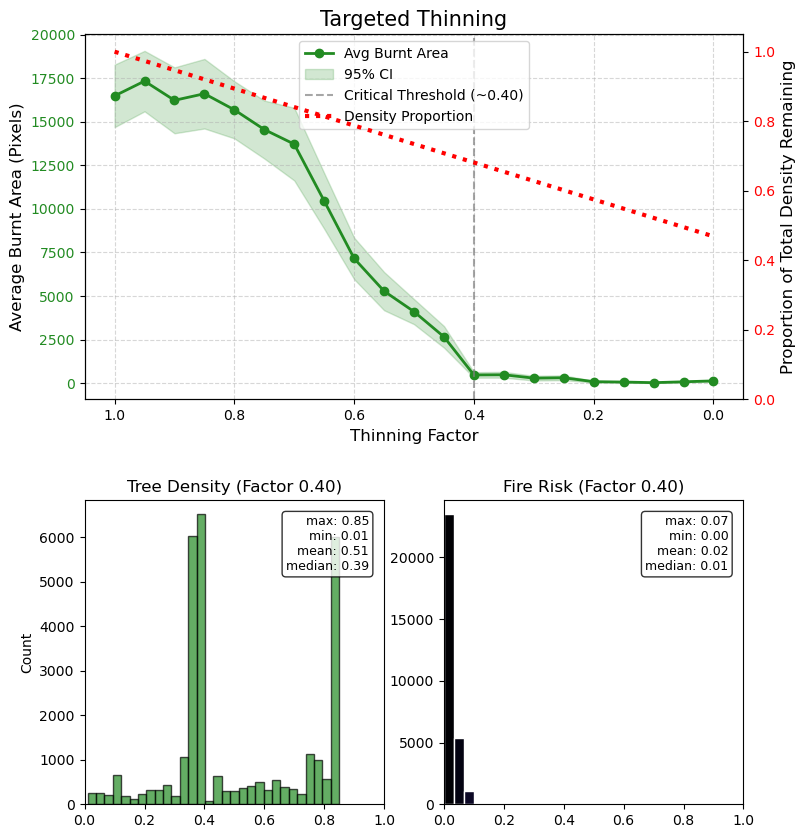

(array([1.  , 0.95, 0.9 , 0.85, 0.8 , 0.75, 0.7 , 0.65, 0.6 , 0.55, 0.5 ,
        0.45, 0.4 , 0.35, 0.3 , 0.25, 0.2 , 0.15, 0.1 , 0.05, 0.  ]),
 array([16480.67889908, 17329.76470588, 16226.32967033, 16605.73170732,
        15681.51376147, 14549.3853211 , 13711.73611111, 10452.03669725,
         7153.28205128,  5277.66942149,  4100.55865922,  2654.23853211,
          468.26666667,   478.31932773,   285.00917431,   307.64220183,
           81.28888889,    61.17592593,    25.58490566,    75.1025641 ,
          127.58715596]),
 array([1794.63113269, 1733.92057051, 1890.42115591, 1995.40161308,
        1639.02194879, 1663.02638297, 2084.01739856, 1597.17323503,
        1189.92282342, 1095.9105026 ,  719.17226653,  619.63849644,
         157.98135567,  166.57035272,  134.96426156,  136.19801022,
          50.06267112,   35.52298403,   13.50409349,   37.62055847,
          52.05168714]))

In [20]:
run_converging_thinning_experiment(sub_density, 0.5, 180, strategy='targeted')